In [4]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

In [7]:
sales = sales.merge(products, on="product_id", how="left")
sales["revenue"] = sales["quantity"] * sales["price"]


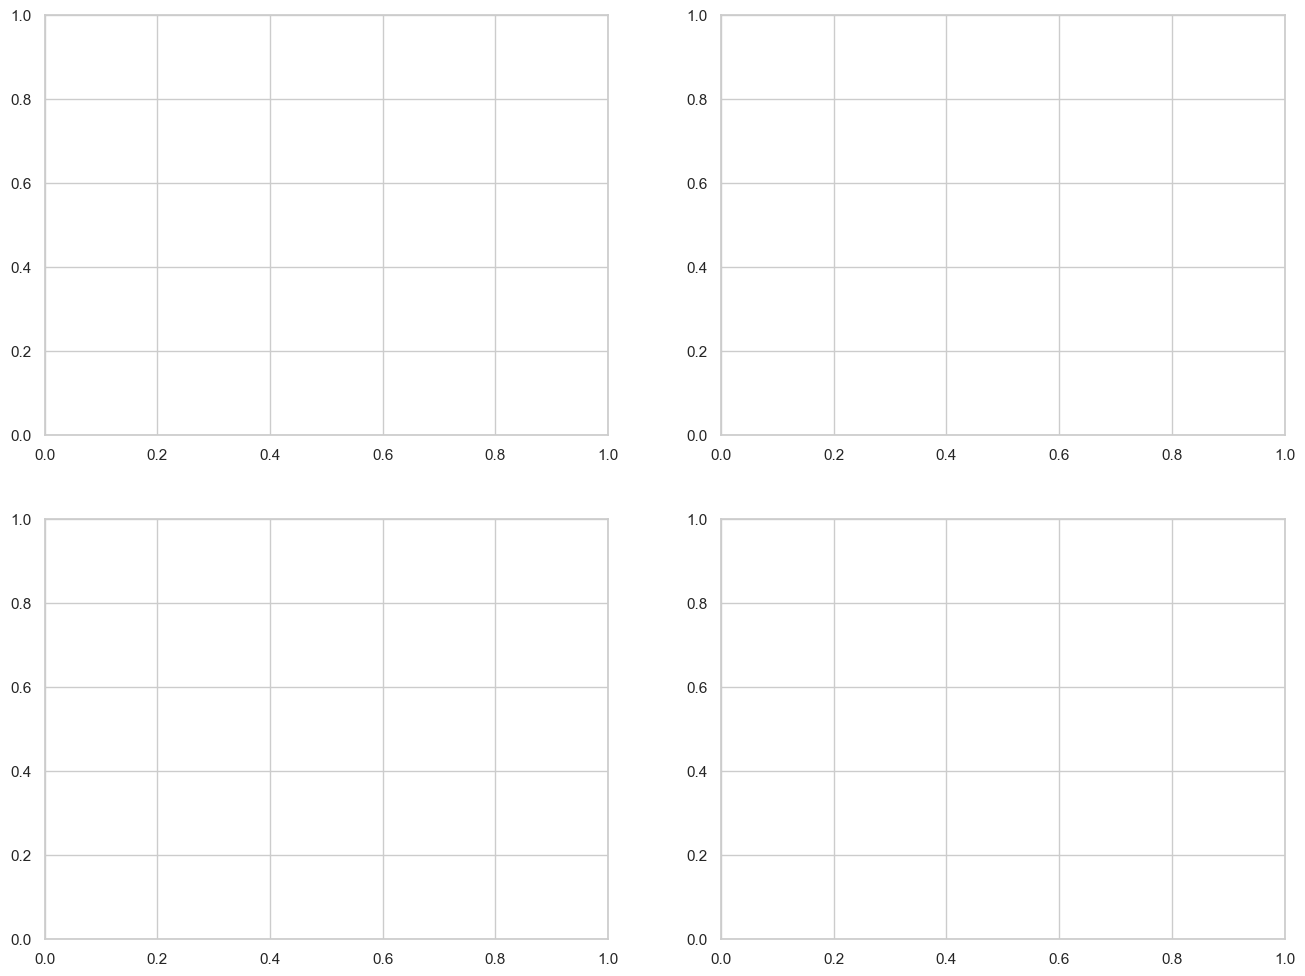

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


In [9]:
rev_by_cat = sales.groupby("category")["revenue"].sum().sort_values()


In [11]:
cust_by_state = customers["state"].value_counts().head(6).sort_values()


<Axes: ylabel='category'>

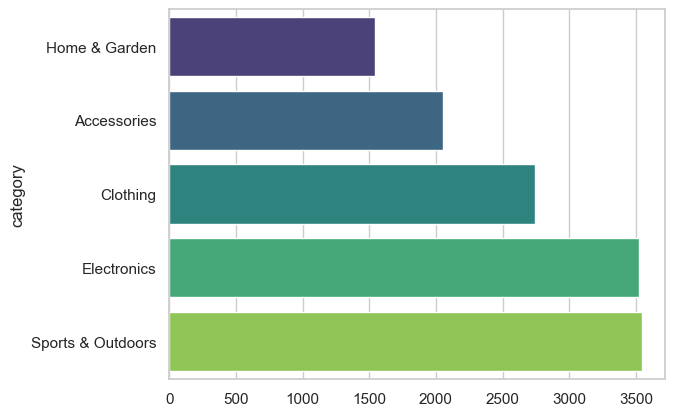

In [13]:
sns.barplot(
    x=rev_by_cat.values,
    y=rev_by_cat.index,
    hue=rev_by_cat.index,
    legend=False,
    palette="viridis"
)


In [15]:
sales.columns


Index(['sale_id', 'customer_id', 'product_id', 'transaction_date', 'quantity',
       'total_amount', 'product_name', 'category', 'price', 'launch_date',
       'brand', 'revenue'],
      dtype='str')

In [16]:
sales["transaction_date"] = pd.to_datetime(sales["transaction_date"], errors="coerce")


In [17]:
sales["day_name"] = sales["transaction_date"].dt.day_name()


In [18]:
avg_by_day = sales.groupby("day_name")["total_amount"].mean()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
avg_by_day = avg_by_day.reindex(order)


In [19]:
sns.lineplot(
    x=avg_by_day.index,
    y=avg_by_day.values,
    ax=axes[1,0],
    marker="o",
    linewidth=2,
    color="steelblue"
)

axes[1,0].set_title("Average Transaction Amount by Day of Week")
axes[1,0].set_xlabel("Day")
axes[1,0].set_ylabel("Avg Transaction Amount ($)")


Text(4.444444444444459, 0.5, 'Avg Transaction Amount ($)')

In [20]:
mean_val = sales["total_amount"].mean()


In [21]:
sns.histplot(
    sales["total_amount"],
    bins=30,
    ax=axes[1,1],
    color="skyblue",
    edgecolor="black"
)

axes[1,1].axvline(mean_val, color="red", linestyle="--", label=f"Mean = ${mean_val:.2f}")
axes[1,1].legend()
axes[1,1].set_title("Distribution of Transaction Amounts")
axes[1,1].set_xlabel("Transaction Amount ($)")
axes[1,1].set_ylabel("Frequency")


Text(680.8080808080806, 0.5, 'Frequency')

In [22]:
cust_sales = sales.groupby("customer_id").agg(
    total_spending=("total_amount", "sum"),
    purchase_count=("total_amount", "count")
).reset_index()

merged = customers.merge(cust_sales, on="customer_id", how="left")
merged["total_spending"] = merged["total_spending"].fillna(0)
merged["purchase_count"] = merged["purchase_count"].fillna(0)


In [23]:
bins = [0, 30, 45, 60, 120]
labels = ["Under 30", "30-45", "46-60", "Over 60"]
merged["age_group"] = pd.cut(merged["age"], bins=bins, labels=labels)


<Axes: xlabel='income', ylabel='total_spending'>

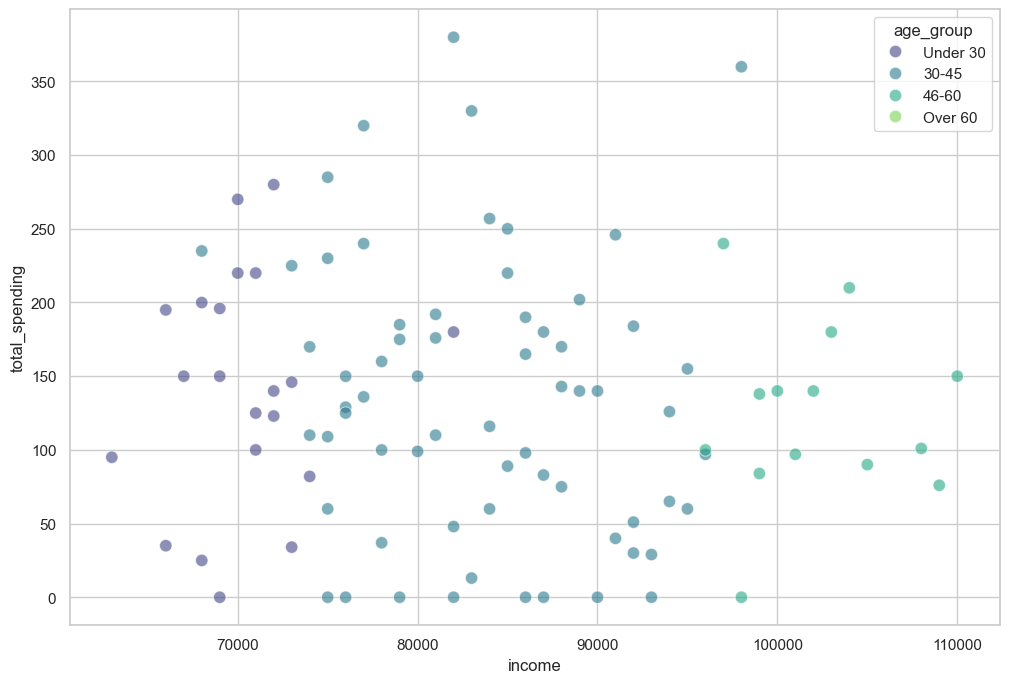

In [24]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=merged,
    x="income",
    y="total_spending",
    hue="age_group",
    alpha=0.6,
    s=80,
    palette="viridis"
)


<Axes: xlabel='income', ylabel='total_spending'>

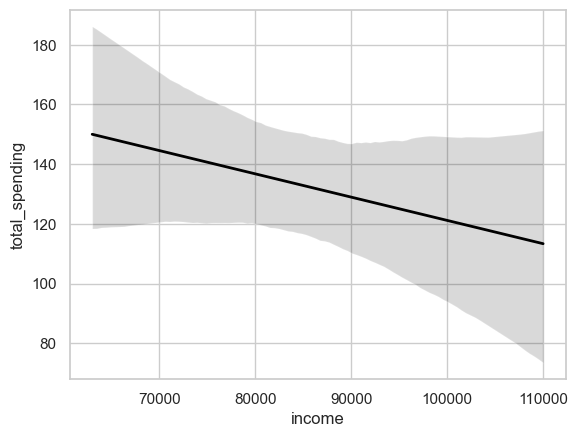

In [25]:
sns.regplot(
    data=merged,
    x="income",
    y="total_spending",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)


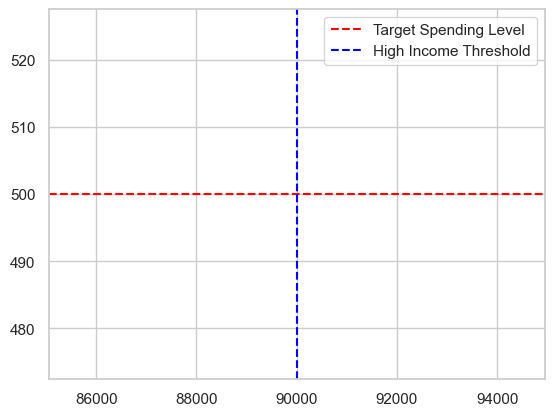

In [26]:
plt.axhline(500, color="red", linestyle="--", label="Target Spending Level")
plt.axvline(90000, color="blue", linestyle="--", label="High Income Threshold")
plt.legend()


Text(0.05, 0.95, 'Correlation: -0.10\nCustomers: 100')

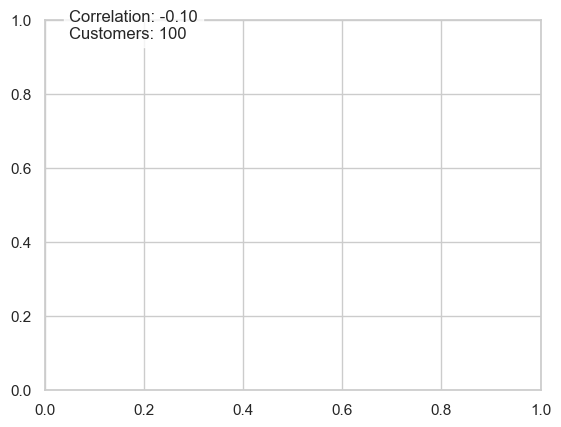

In [27]:
corr = merged["income"].corr(merged["total_spending"])

plt.text(
    0.05, 0.95,
    f"Correlation: {corr:.2f}\nCustomers: {len(merged)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)


Text(102000.0, 336.955, 'Top Age Group: Under 30')

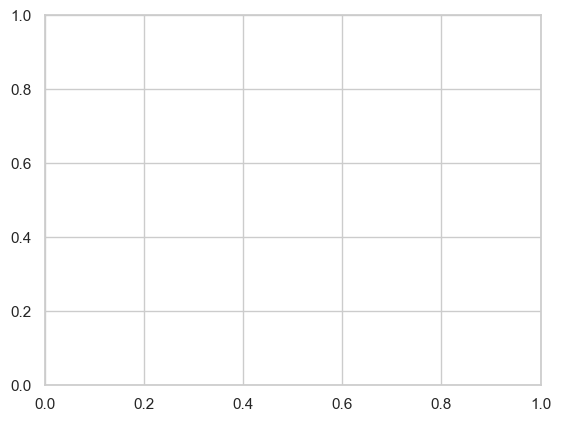

In [28]:
top_group = merged.groupby("age_group")["total_spending"].mean().idxmax()

plt.annotate(
    f"Top Age Group: {top_group}",
    xy=(merged["income"].median(), merged["total_spending"].median()),
    xytext=(merged["income"].median()+20000, merged["total_spending"].median()+200),
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(facecolor="white", alpha=0.8)
)
